<a href="https://www.kaggle.com/code/bhaveshyadav111/stroke-prediction-engine?scriptVersionId=349288200" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np 


# Libararies required

In [2]:
!pip install imbalanced-learn --quiet

In [3]:
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score,confusion_matrix
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [4]:
from pathlib import Path
import joblib


In [5]:
data_path = Path('/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset')
data_path

PosixPath('/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset')

In [6]:
import os
os.listdir(data_path)

['healthcare-dataset-stroke-data.csv']

In [7]:
df = pd.read_csv(f'{data_path}/healthcare-dataset-stroke-data.csv')

In [8]:
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
216,2390,Male,78.00,0,0,Yes,Self-employed,Urban,116.10,27.1,never smoked,1
321,39038,Male,11.00,0,0,No,children,Rural,79.03,16.5,Unknown,0
2540,14372,Male,50.00,0,0,Yes,Self-employed,Urban,192.16,43.6,never smoked,0
2790,2707,Male,10.00,0,0,No,children,Rural,68.94,18.0,Unknown,0
4293,69222,Male,0.24,0,0,No,children,Urban,57.09,19.4,Unknown,0


# EDA

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [10]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [11]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [12]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [13]:
px.scatter(df,x='age',y='avg_glucose_level',color='smoking_status')

In [14]:
px.scatter(df,x='age',y='bmi',color='work_type')

as the data shown above , can conclude that people in private work have a low or standard/ balanced BMI as compared to people working in government jobs.

But we can't conclude children and never - worked data because few data is present here about these.

<Axes: xlabel='ever_married', ylabel='stroke'>

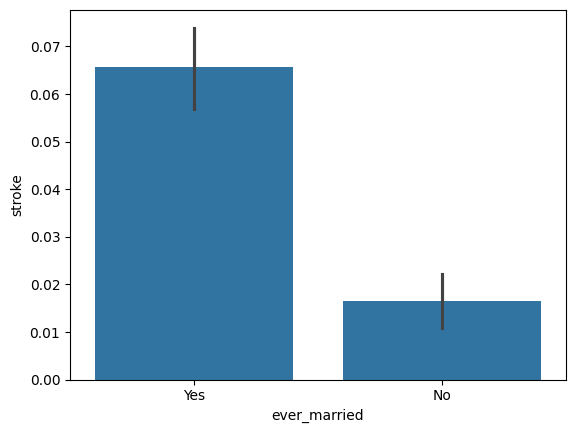

In [15]:
sns.barplot(df,x='ever_married',y='stroke')

One unexpected feature that is Ever_married affects a lot whether a person has stroke or not . From analysis we conclude married person have high chances of stroke.

<Axes: xlabel='bmi', ylabel='work_type'>

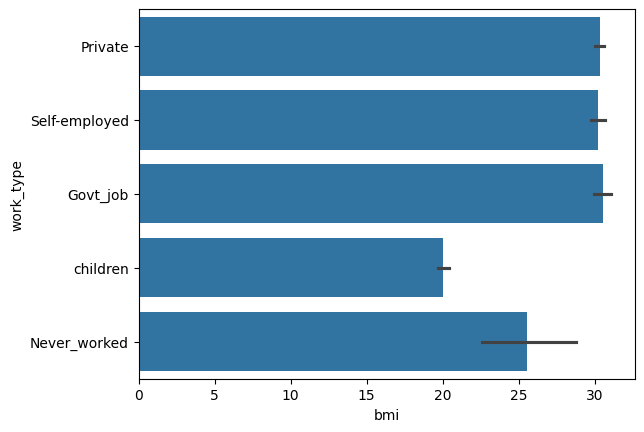

In [16]:
sns.barplot(df,x='bmi',y='work_type')

<Axes: xlabel='stroke', ylabel='Residence_type'>

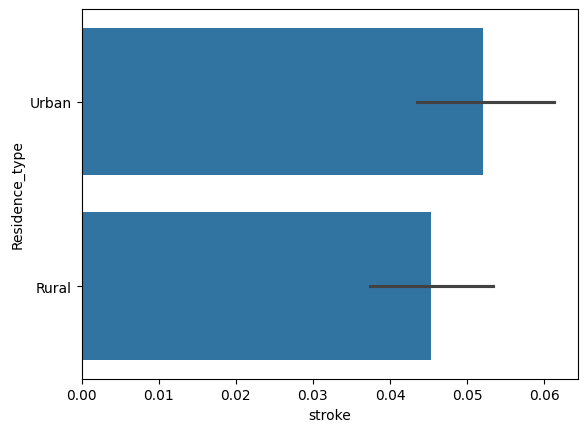

In [17]:
sns.barplot(df,x='stroke',y='Residence_type')

As we look at Residence type of people , the people who live in Urban areas have more probability stroke

In [18]:
df.Residence_type.value_counts()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

In [19]:
names = ['Urban','Rural']

([<matplotlib.patches.Wedge at 0x7ec8df96c560>,
 [Text(-0.027724334424490793, 1.0996505632612203, 'Urban'),
  Text(0.02772429947043765, -1.0996505641424796, 'Rural')],
 [Text(-0.01512236423154043, 0.5998093981424838, '50.80%'),
  Text(0.015122345165693264, -0.5998093986231706, '49.20%')])

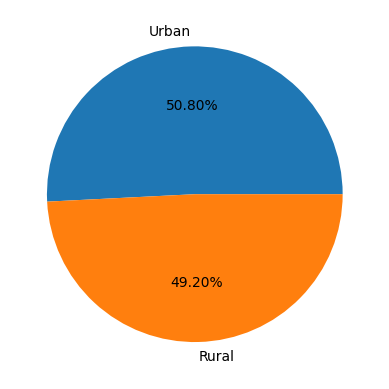

In [20]:
plt.pie(df.Residence_type.value_counts(),labels=names,autopct='%1.2f%%')

In [21]:
stroke_name = ['no','yes']

In [22]:
df.stroke.value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x7ec8df888ad0>,
 [Text(-1.0871361482645023, 0.16773489540528563, 'no'),
  Text(1.087136202919411, -0.16773454117135664, 'yes')],
 [Text(-0.5929833535988194, 0.0914917611301558, '95.13%'),
  Text(0.5929833834105878, -0.09149156791164906, '4.87%')])

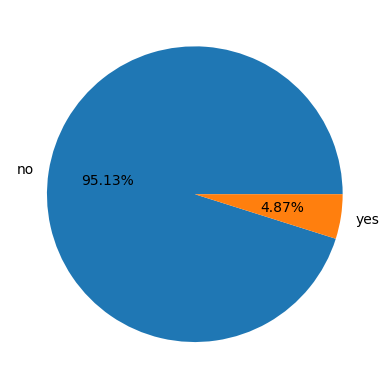

In [23]:
plt.pie(df.stroke.value_counts(),labels=stroke_name,autopct='%1.2f%%')

In [24]:
px.histogram(df,'stroke')

our data is bias , needs to follow some steps 

-> Penalize the majority class

-> Use alogrithm robust to imbalancement like Random Forest , XGBoost

In [25]:
df.corr(numeric_only=True)['stroke'].sort_values(ascending=False)

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374
id                   0.006388
Name: stroke, dtype: float64

# Preprocessing

As the data is imbalance , let's try to make it balance by using Undersampling and Oversampling and see how it affects the prediction of different models.

In [26]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [27]:
df.bmi.fillna(df.bmi.mean(),inplace=True)

/tmp/ipykernel_16/799814321.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





## input & Output selection

In [28]:
input_cols = df.columns[1:-1].tolist()
target = 'stroke'

In [29]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


## train ,validation & test split

In [30]:
train_val,test = train_test_split(df,test_size=0.25,random_state=1)
train,val = train_test_split(train_val,test_size=0.25,random_state=1)

x_train = train[input_cols]
x_val = val[input_cols]
x_test = test[input_cols]

y_train = train[target]
y_val = val[target]
y_test = test[target]

## Identify Numerical and Categorical features 

In [31]:
num_cols = x_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = x_train.select_dtypes(include='object').columns.tolist()

### adjust features type

In [32]:
num_cols = ['age','avg_glucose_level','bmi']

As , get biased data needs to handle it with OverSampling using -> ***SMOTENC***(Synthetic Minority Over-sampling technique for nominal and categorical features)

### Handling Numerical features

In [33]:
num_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

### handling Categorical features

In [34]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

In [35]:
preprocessor = ColumnTransformer([
    ('num',num_pipe,num_cols),
    ('cat',cat_pipe,cat_cols)
])


In [36]:
cat_indices = [
    x_train.columns.get_loc(col)
    for col in cat_cols
]

# Models(ALGORITHMs)

In [37]:
# models 
lg = Pipeline([
    ('oversample', SMOTENC(categorical_features=cat_indices,random_state=1)),
    
    ('preprocess',preprocessor),
    ('lgCV_model',LogisticRegressionCV(max_iter=1000,cv=5,solver='lbfgs'))
])

nb = Pipeline([
    ('oversample', SMOTENC(categorical_features=cat_indices,random_state=1)),
    
    ('preprocess',preprocessor),
    ('nb_model',GaussianNB())
])

svc = Pipeline([
    ('oversample', SMOTENC(categorical_features=cat_indices,random_state=1)),
    
    ('preprocess',preprocessor),
    ('svc_model',SVC(probability=True,kernel='linear',class_weight=({0:1,1:2})))
])

dt = Pipeline([
    ('oversample', SMOTENC(categorical_features=cat_indices,random_state=1)),
    ('preprocess',preprocessor),
    ('Dt_model',DecisionTreeClassifier(max_depth=4,random_state=1))
])

rdf = Pipeline([
    ('oversample', SMOTENC(categorical_features=cat_indices,random_state=1)),
    ('preprocess',preprocessor),
    ('rdf_model',RandomForestClassifier(n_estimators=100,bootstrap=True,max_depth=5,random_state=1))
])

In [38]:
print('RECALL_SCORE')
print('*************')

for model,name in [(lg,'logisticCV'),(nb,'Naive Bayes'),(svc,"SVM"),(dt,'Decision Tree'),(rdf,'Random Forest')]:
    model.fit(x_train,y_train)

    print(name)
    pred_train = model.predict(x_train)
    pred_val = model.predict(x_val)
    pred_test = model.predict(x_test)
    print('-------------------------------')
    print('train acc :',recall_score(y_train,pred_train))
    print('val acc :',recall_score(y_val,pred_val))
    print('test acc :',recall_score(y_test,pred_test))
    print('-------------------------------')
    

RECALL_SCORE
*************
logisticCV
-------------------------------
train acc : 0.6796875
val acc : 0.7608695652173914
test acc : 0.6533333333333333
-------------------------------
Naive Bayes
-------------------------------
train acc : 0.78125
val acc : 0.8695652173913043
test acc : 0.8933333333333333
-------------------------------
SVM
-------------------------------
train acc : 0.8125
val acc : 0.9347826086956522
test acc : 0.8133333333333334
-------------------------------
Decision Tree
-------------------------------
train acc : 0.7265625
val acc : 0.6304347826086957
test acc : 0.5866666666666667
-------------------------------
Random Forest
-------------------------------
train acc : 0.7265625
val acc : 0.717391304347826
test acc : 0.5466666666666666
-------------------------------


# HyperParam tuning

In [39]:
!pip install joblib --quiet

In [40]:
for regular in [0.2,0.4,0.5,0.7,0.8,1.0] : 
    svc = Pipeline([
        ('oversample', SMOTENC(categorical_features=cat_indices,random_state=1)),
        ('preprocess',preprocessor),
        ('svc_model',SVC(probability=True,kernel='linear',C=regular))
    ])
    svc.fit(x_train,y_train)
    y_pred = svc.predict(x_test)
    print(recall_score(y_test,y_pred))

0.6933333333333334
0.6933333333333334
0.6933333333333334
0.6933333333333334
0.6933333333333334
0.6933333333333334


For SVC linear kernel function is best.

## LogisticRegressionCV Decision Tree and Random Forest Tuning

In [41]:
params = {
    'Dt_model__max_depth' : [depth for depth in range(3,15)],
    'Dt_model__min_samples_split' : [split for split in range(2,20)],
    'Dt_model__ccp_alpha' : [0.001,0.01,0.1,0.02,0.03,0.2],
    'Dt_model__max_features' : [maxF/10 for maxF in range(3,9)]
}
dt_final = RandomizedSearchCV(dt,param_distributions=params,cv=5,n_iter=10,scoring="recall",random_state=1).fit(x_train,y_train)

In [42]:
dt_final.best_params_

{'Dt_model__min_samples_split': 4,
 'Dt_model__max_features': 0.8,
 'Dt_model__max_depth': 3,
 'Dt_model__ccp_alpha': 0.02}

In [43]:
y_pred = dt_final.predict(x_test)
print('train_acc',recall_score(y_train,dt_final.predict(x_train)))
print('test_acc',recall_score(y_test,y_pred))
print('roc_auc_score ',roc_auc_score(y_test,y_pred))

train_acc 0.8984375
test_acc 0.9466666666666667
roc_auc_score  0.7767414796342478


In [44]:
svc.predict_proba(x_test)

array([[0.94084751, 0.05915249],
       [0.06196829, 0.93803171],
       [0.96051257, 0.03948743],
       ...,
       [0.98402305, 0.01597695],
       [0.99324039, 0.00675961],
       [0.9513325 , 0.0486675 ]], shape=(1278, 2))

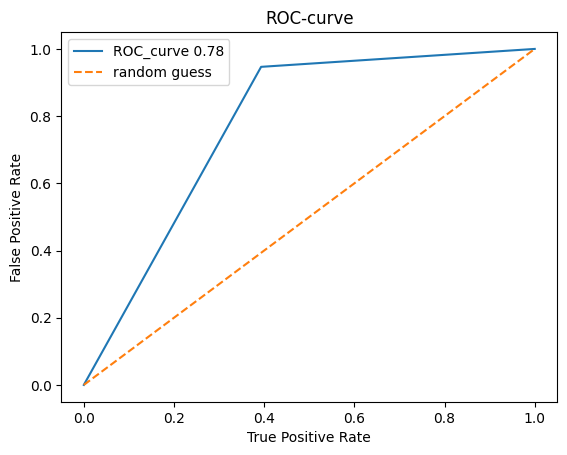

In [45]:
y_pred = dt_final.predict_proba(x_test)[:,1]

fpr,tpr,thersholds = roc_curve(y_test,y_pred)
plt.title("ROC-curve")
plt.plot(fpr,tpr,label=f'ROC_curve {roc_auc_score(y_test,y_pred):.2f}')
plt.plot([0,1],[0,1],linestyle='--',label="random guess")

plt.xlabel('True Positive Rate')
plt.ylabel('False Positive Rate')
plt.legend()

In [46]:
params = {
    'rdf_model__max_depth': [3,4,6,7,8],
    'rdf_model__min_samples_split': [2, 5, 10, 15, 20],
    'rdf_model__min_samples_leaf': [4,7,12,15,20],
    'rdf_model__ccp_alpha': [0, 0.0001, 0.001, 0.005, 0.01, 0.02],
    'rdf_model__max_features': [0.3, 0.4, 0.5, 0.6,'log2']
}

rdf_final = RandomizedSearchCV(
    rdf,
    param_distributions=params,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=1,
    n_jobs=-1
)

rdf_final.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('oversample',
                                              SMOTENC(categorical_features=[0,
                                                                            4,
                                                                            5,
                                                                            6,
                                                                            9],
                                                      random_state=1)),
                                             ('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'avg_glucose_level',
                                                                                'bmi']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_fre...
                                              RandomForestClassifier(max_depth=5,
                                                                     random_state=1))]),
                   n_jobs=-1,
                   param_distributions={'rdf_model__ccp_alpha': [0, 0.0001,
                                                                 0.001, 0.005,
                                                                 0.01, 0.02],
                                        'rdf_model__max_depth': [3, 4, 6, 7, 8],
                                        'rdf_model__max_features': [0.3, 0.4,
                                                                    0.5, 0.6,
                                                                    'log2'],
                                        'rdf_model__min_samples_leaf': [4, 7,
                                                                        12, 15,
                                                                        20],
                                        'rdf_model__min_samples_split': [2, 5,
                                                                         10, 15,
                                                                         20]},
                   random_state=1, scoring='recall')

In [47]:
rdf_final.best_score_

np.float64(0.7353846153846153)

In [48]:
y_pred = rdf_final.predict(x_test)
print(recall_score(y_train,rdf_final.predict(x_train)))
print(recall_score(y_test,y_pred))
print('roc_auc_score ',roc_auc_score(y_test,y_pred))

0.7734375
0.9066666666666666
roc_auc_score  0.776691604322527


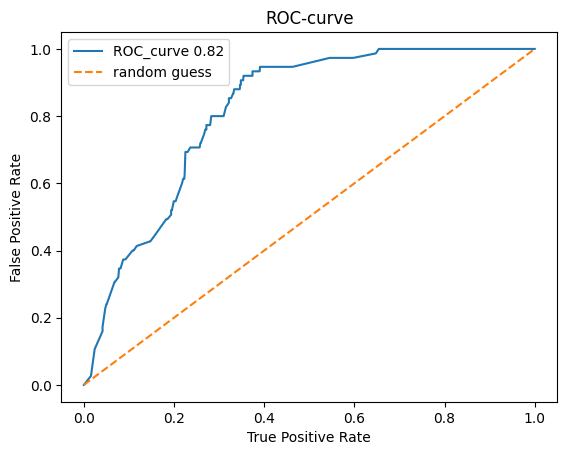

In [49]:
y_pred = rdf_final.predict_proba(x_test)[:,1]
fpr,tpr,thersholds = roc_curve(y_test,y_pred)
plt.title("ROC-curve")
plt.plot(fpr,tpr,label=f'ROC_curve {roc_auc_score(y_test,y_pred):.2f}')
plt.plot([0,1],[0,1],linestyle='--',label="random guess")

plt.xlabel('True Positive Rate')
plt.ylabel('False Positive Rate')
plt.legend()

In [50]:
params = {
    'lgCV_model__Cs' : [1,2,3,4,5,6]
}
lg_final = RandomizedSearchCV(lg,param_distributions=params,n_iter=20,scoring='recall',cv=5,random_state=1).fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning:

The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.



# Voting and Stacking Classifiers


In [51]:
# from sklearn.ensemble import VotingClassifier

# final_model = VotingClassifier(estimators=[
#     ('lg',lg_final),
#     ('dt',dt_final),
#     ('rdf',rdf_final),
#     ('nb',nb)
# ],voting='soft')

# final_model.fit(x_train,y_train)

# pred_train = final_model.predict(x_train)
# pred_val = final_model.predict(x_val)
# pred_test = final_model.predict(x_test)
# print('-------------------------------')
# print('train acc :',recall_score(y_train,pred_train))
# print('val acc :',recall_score(y_val,pred_val))
# print('test acc :',recall_score(y_test,pred_test))
# print('-------------------------------')

In [52]:
# from sklearn.ensemble import StackingClassifier

# stack_model = StackingClassifier(
#     estimators=[
#         ('lg',svc),
#         ('rdf',rdf_final),
#         ('nb',nb)
#     ],
#     final_estimator=dt_final,
#     cv = 5
# )

# stack_model.fit(x_train,y_train)

# pred_train = stack_model.predict(x_train)
# pred_val = stack_model.predict(x_val)
# pred_test = stack_model.predict(x_test)
# print('-------------------------------')
# print('train acc :',recall_score(y_train,pred_train))
# print('val acc :',recall_score(y_val,pred_val))A
# print('test acc :',recall_score(y_test,pred_test))A
# print('-------------------------------')

In [53]:
models = {
    'rdf_final' : rdf_final,
    'svc' : svc,
    'nb' : nb,
    'dt_final' :dt_final 
}

joblib.dump(models,'stroke_pred_model.pkl')

['stroke_pred_model.pkl']

# Using Neural networks to solve

In [54]:
cat_cols = x_train.select_dtypes('object').columns.tolist()

In [55]:
over = SMOTENC(categorical_features=cat_cols,random_state=1)
over_x_train,over_y_train = over.fit_resample(x_train,y_train)

In [56]:
num_cols = x_train.select_dtypes(np.number).columns.tolist()

In [57]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoder.fit(over_x_train[cat_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [58]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

In [59]:
over_x_train[encoded_cols] = encoder.transform(over_x_train[cat_cols])
x_test[encoded_cols] = encoder.transform(x_test[cat_cols])

/tmp/ipykernel_16/1047858434.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [60]:
new_inputs = num_cols + encoded_cols.tolist()

In [61]:
over_x_train = over_x_train[new_inputs]
x_test = x_test[new_inputs]

In [62]:
scaler = StandardScaler().fit(over_x_train)
over_x_train = scaler.transform(over_x_train)
x_test = scaler.transform(x_test)

In [63]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Flatten,Dropout
from keras import Sequential
import keras_tuner as kt

2026-09-12 13:53:00.819165: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789221181.163503      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789221181.250952      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789221182.142269      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789221182.142314      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789221182.142317      16 computation_placer.cc:177] computation placer alr

In [64]:
def build_model(hp):
    model = Sequential()
    cnt = 0
    opt = hp.Choice("optimizers",values=['adam','sgd','nadam','rmsprop','adagrad'])
    for i in range(hp.Int("layers",min_value=1,max_value=10)):
        units = hp.Int("units",min_value=8,max_value=128)

        if cnt == 0:
            model.add(Dense(units=units,activation='relu',input_dim=20))
        model.add(Dense(units=units,activation='relu',kernel_regularizer=keras.regularizers.l2(0.01)))
        model.add(Dropout(0.3))
        cnt+=1
    
    model.add(Dense(1,activation='sigmoid'))
    model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['accuracy'])
    
    return model

In [65]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    directory="mydir",
    project_name="prj1"
)
with tensorflow.device('/GPU:0'):
    tuner.search(over_x_train,over_y_train,epochs=5,validation_data=(x_test,y_test))

Trial 5 Complete [00h 00m 07s]
val_loss: 0.5385874509811401

Best val_loss So Far: 0.5080323815345764
Total elapsed time: 00h 00m 43s


In [66]:
tuner.get_best_hyperparameters()[0].values

{'optimizers': 'rmsprop', 'layers': 5, 'units': 38}

In [67]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning:

Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 16 variables. 



In [68]:
history = model.fit(over_x_train,over_y_train,epochs=200,verbose=0,validation_data=(x_test,y_test),initial_epoch=6,batch_size=1_000)

In [69]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 38)             │           798 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         1,482 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         1,482 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         1,482 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 38)             │         1,482 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         1,482 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 38)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,496 (64.44 KB)

 Trainable params: 8,247 (32.21 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,249 (32.23 KB)

In [70]:
y_log = model.predict(x_test)

y_pred = np.where(y_log>=0.5,1,0)
y_pred1 = model.predict(over_x_train)
y_pred2  = np.where(y_pred1>=0.5,1,0)

recall_score(y_test,y_pred)
# recall_score(over_y_train,y_pred2)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.3333333333333333

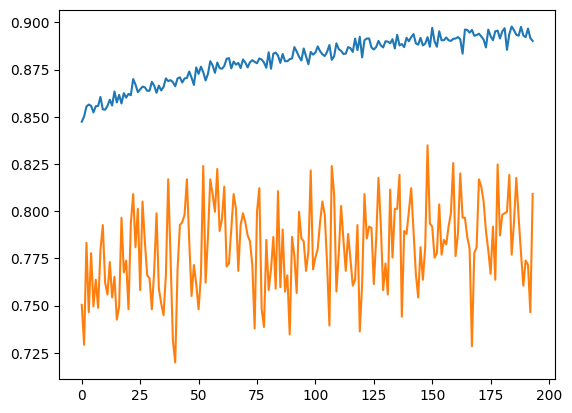

In [71]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])